In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [10]:
class DataProcessor:
    def __init__(self, url):
        column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
                        'Acceleration', 'Model Year', 'Origin']
        # Fetching from UCI pointed by "url"
        self.raw_dataset = pd.read_csv(url, names=column_names,
                          na_values='?', comment='\t',
                          sep=' ', skipinitialspace=True)
        self.scaler = StandardScaler()

    def clean_and_prepare(self):
        # Remove null values

        print(self.raw_dataset.head())
        df = self.raw_dataset.dropna()
        
        # One-hot encode 'Origin' 
        df = pd.get_dummies(df, columns=['Origin'], prefix='', prefix_sep='')
        
        # Split features and labels
        X = df.drop('MPG', axis=1)
        y = df['MPG']
        
        # Split into Train, Val, Test (80-10-10%)
        X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
        X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
        
        # Feature Scaling
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_val_scaled = self.scaler.transform(X_val)
        X_test_scaled = self.scaler.transform(X_test)
        
        return (X_train_scaled, y_train), (X_val_scaled, y_val), (X_test_scaled, y_test)

In [11]:
# 1. Initialize and Process Data
data_url = "http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
processor = DataProcessor(data_url)
train, val, test = processor.clean_and_prepare()

    MPG  Cylinders  Displacement  Horsepower  Weight  Acceleration  \
0  18.0          8         307.0       130.0  3504.0          12.0   
1  15.0          8         350.0       165.0  3693.0          11.5   
2  18.0          8         318.0       150.0  3436.0          11.0   
3  16.0          8         304.0       150.0  3433.0          12.0   
4  17.0          8         302.0       140.0  3449.0          10.5   

   Model Year  Origin  
0          70       1  
1          70       1  
2          70       1  
3          70       1  
4          70       1  


In [12]:
class FuelPredictorModel:
    def __init__(self, input_shape):
        self.model = self._build_model(input_shape)

    def _build_model(self, input_shape):
        model = tf.keras.Sequential([
            tf.keras.layers.Dense(64, activation='relu', input_shape=[input_shape]),
            tf.keras.layers.Dense(64, activation='relu'),
            tf.keras.layers.Dense(1) # Single output for regression
        ])

        model.compile(
            optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-3),
            loss='mse',
            metrics=['mae', 'mse'] # Mean Absolute Error & Mean Squared Error
        )
        return model

    def train(self, train_data, val_data, epochs=100):
        X_train, y_train = train_data
        early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)
        
        history = self.model.fit(
            X_train, y_train,
            epochs=epochs,
            validation_data=val_data,
            verbose=1,
            callbacks=[early_stop]
        )
        return history

In [13]:
# 2. Build and Train
input_dim = train[0].shape[1]
predictor = FuelPredictorModel(input_dim)
print("Training model...")
history = predictor.train(train, val, epochs=20)

# 3. Evaluate on Test Set
test_results = predictor.model.evaluate(test[0], test[1], verbose=0)
print(f"\nTest Metrics - MAE: {test_results[1]:.2f} MPG")

Training model...
Epoch 1/20


/home/master_nilesh/Tensorflow/TF_GPU/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 207ms/step - loss: 581.0773 - mae: 22.7588 - mse: 581.0773 - val_loss: 441.1745 - val_mae: 19.9979 - val_mse: 441.1745
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 510.8799 - mae: 21.1642 - mse: 510.8799 - val_loss: 374.1098 - val_mae: 18.2675 - val_mse: 374.1098
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 436.7277 - mae: 19.3653 - mse: 436.7277 - val_loss: 300.9860 - val_mae: 16.2050 - val_mse: 300.9860
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 354.1905 - mae: 17.1916 - mse: 354.1905 - val_loss: 226.0041 - val_mae: 13.7937 - val_mse: 226.0041
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 271.1731 - mae: 14.7257 - mse: 271.1731 - val_loss: 158.7129 - val_mae: 11.3310 - val_mse: 158.7129
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 193.4586 - mae: 12.1460 - mse: 193.4586 - val_loss: 100.2728 - val_mae: 8.7089 - val_mse: 100.2728
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss

In [14]:
# 4. Inferencing on "Unknown" Data
# Simulating a new car: 4 cylinders, 121 displacement, 110 hp, 2800 weight, 15.4 accel, 81 built year
unknown_car = np.array([[4, 121.0, 110.0, 2800.0, 15.4, 81, 0, 1, 0]]) 
unknown_car_scaled = processor.scaler.transform(unknown_car)

prediction = predictor.model.predict(unknown_car_scaled)
print(f"Predicted Fuel Efficiency: {prediction[0][0]:.2f} MPG")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step

/home/master_nilesh/Tensorflow/TF_GPU/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
Predicted Fuel Efficiency: 26.32 MPG


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 240ms/step


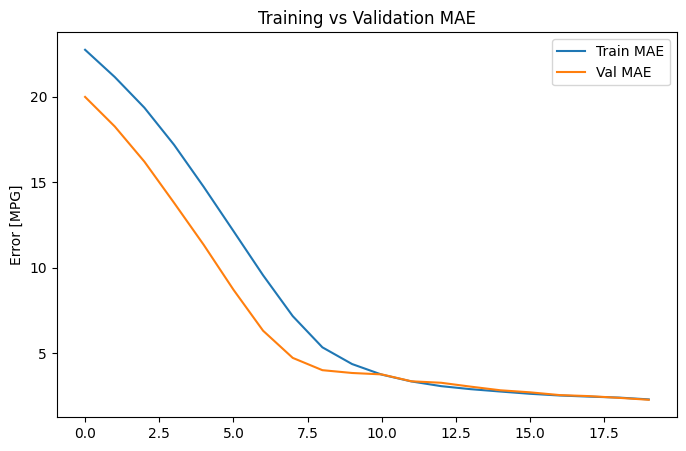

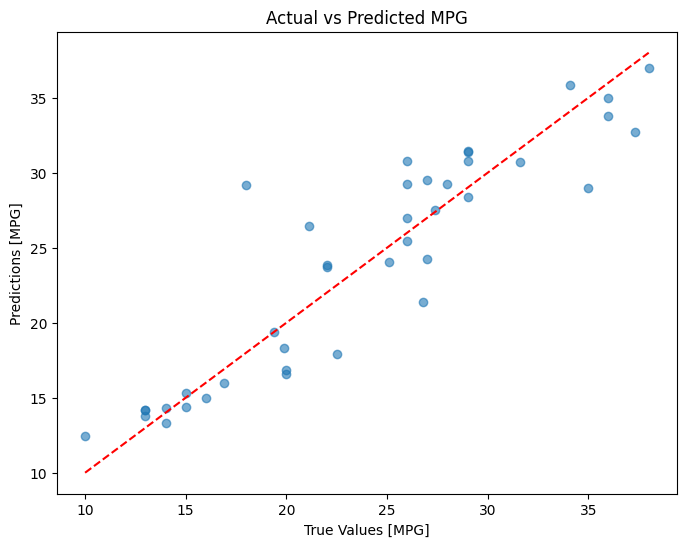

In [15]:
# 5. Plot Training Metrics
plt.figure(figsize=(8, 5))
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Training vs Validation MAE')
plt.ylabel('Error [MPG]')
plt.legend()
plt.savefig('training_history.png')

# 4. Inferencing on Unknown Data
test_predictions = predictor.model.predict(test[0]).flatten()
plt.figure(figsize=(8, 6))
plt.scatter(test[1], test_predictions, alpha=0.6)
plt.plot([test[1].min(), test[1].max()], [test[1].min(), test[1].max()], 'r--')
plt.xlabel('True Values [MPG]')
plt.ylabel('Predictions [MPG]')
plt.title('Actual vs Predicted MPG')
plt.savefig('prediction_accuracy.png')

In [16]:
# Notes - 

# Variance is higher in the testing phase signifying high complexity of model capturing noise